# Name: Malak Gamal Ahmed Sanad Eleza
# ID: 221000014

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('Breast Cancer METABRIC.csv')

# Basic overview
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nStatistical summary:\n", df.describe())

# Missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

# Target distribution
print("\nTarget distribution:")
print(df['Overall Survival Status'].value_counts())
print(df['Overall Survival Status'].value_counts(normalize=True).round(3))

Shape: (2509, 34)

Column names:
 ['Patient ID', 'Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC', 'ER Status', 'Neoplasm Histologic Grade', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'PR Status', 'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status', 'Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage', "Patient's Vital Status"]

Data types:
 Patient ID                         object
Age at Diagnosis                  float64
Type of Breast Surgery             object
Cancer Type                        object
Cancer Type Detailed          

In [3]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# ── 2.1 Drop rows where target is missing ──────────────────────────────────
df = df[df['Overall Survival Status'].notna()].copy()
print(f"Rows after dropping missing target: {len(df)}")

# ── 2.2 Encode target variable ─────────────────────────────────────────────
df['Target'] = df['Overall Survival Status'].map({'Living': 0, 'Deceased': 1})

# ── 2.3 Drop leaky, redundant, and high-missingness columns ───────────────
drop_cols = [
    'Patient ID',                    # identifier, not predictive
    'Sex',                           # all female in this dataset
    'Cancer Type',                   # redundant with detailed version
    'Oncotree Code',                 # redundant clinical code
    'Cancer Type Detailed',          # too granular, low signal
    'Tumor Stage',                   # 72% missing
    '3-Gene classifier subtype',     # 75% missing
    "Patient's Vital Status",        # LEAKY — directly encodes the outcome
    'Overall Survival (Months)',     # LEAKY — survival time implies outcome
    'Relapse Free Status (Months)',  # LEAKY — strongly correlated with target
    'Overall Survival Status',       # the original target column
]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

print(f"Columns after dropping: {df.shape[1]}")

# ── 2.4 Separate numeric and categorical columns ───────────────────────────
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Target').tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\nNumeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

# ── 2.5 Impute missing values ──────────────────────────────────────────────
num_imp = SimpleImputer(strategy='median')        # median is robust to outliers
cat_imp = SimpleImputer(strategy='most_frequent') # mode for categorical

df[num_cols] = num_imp.fit_transform(df[num_cols])
df[cat_cols] = cat_imp.fit_transform(df[cat_cols])

# Verify no missing values remain
assert df.isnull().sum().sum() == 0, "Still has NaN after imputation!"
print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")

Rows after dropping missing target: 1981
Columns after dropping: 24

Numeric columns (7): ['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Tumor Size']
Categorical columns (16): ['Type of Breast Surgery', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER status measured by IHC', 'ER Status', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'PR Status', 'Radio Therapy', 'Relapse Free Status']

Missing values after imputation: 0
Final shape: (1981, 24)


In [4]:
# ── 3.1 Create composite risk score ────────────────────────────────────────
# Clinical rationale: a high-grade tumor with lymph node spread carries
# compounded risk — this feature encodes that interaction explicitly.
df['High_Grade_Lymph_Risk'] = (
    df['Neoplasm Histologic Grade'] * (df['Lymph nodes examined positive'] + 1)
).round(2)

print("New feature 'High_Grade_Lymph_Risk' created.")
print(df['High_Grade_Lymph_Risk'].describe())

# ── 3.2 Label-encode all categorical columns for ML ─────────────────────
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# ── 3.3 Prepare feature matrix and target vector ────────────────────────
X = df.drop(columns=['Target'])
y = df['Target']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

New feature 'High_Grade_Lymph_Risk' created.
count    1981.000000
mean        7.490661
std        11.349834
min         1.000000
25%         2.000000
50%         3.000000
75%         7.000000
max       138.000000
Name: High_Grade_Lymph_Risk, dtype: float64

Feature matrix shape: (1981, 24)
Target shape: (1981,)
Target distribution:
Target
1    1144
0     837
Name: count, dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Reload original for plotting with original labels
df_orig = pd.read_csv('Breast Cancer METABRIC.csv')
df_orig = df_orig[df_orig['Overall Survival Status'].notna()]


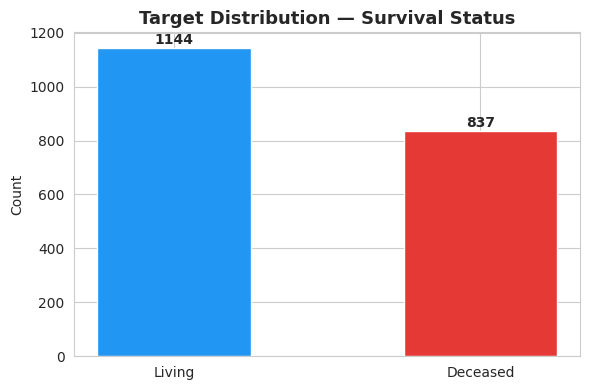

In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# ── Plot 1: Target distribution (bar chart) ─────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = y.value_counts()
bars = ax.bar(['Living', 'Deceased'], counts.values,
               color=['#2196F3', '#E53935'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15, str(val), ha='center', fontweight='bold')
ax.set_title('Target Distribution — Survival Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')

# Create the 'plots' directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

plt.tight_layout(); plt.savefig('plots/01_target_distribution.png', dpi=150); plt.show()

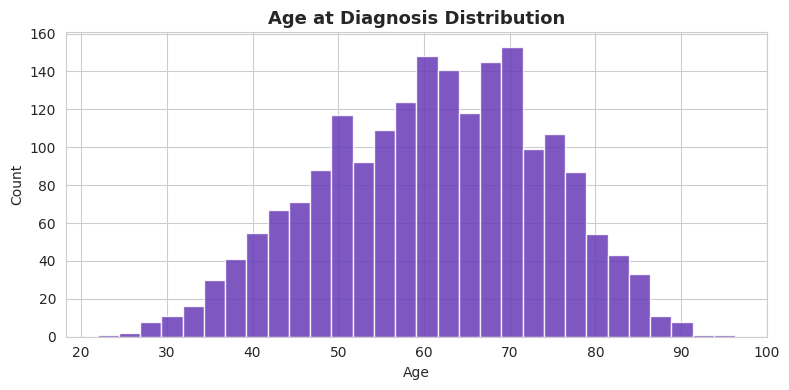

In [13]:
# ── Plot 2: Age at diagnosis histogram (univariate) ─────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_orig['Age at Diagnosis'].dropna(), bins=30,
        color='#673AB7', edgecolor='white', alpha=0.85)
ax.set_title('Age at Diagnosis Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Count')
plt.tight_layout(); plt.savefig('plots/02_age_histogram.png', dpi=150); plt.show()


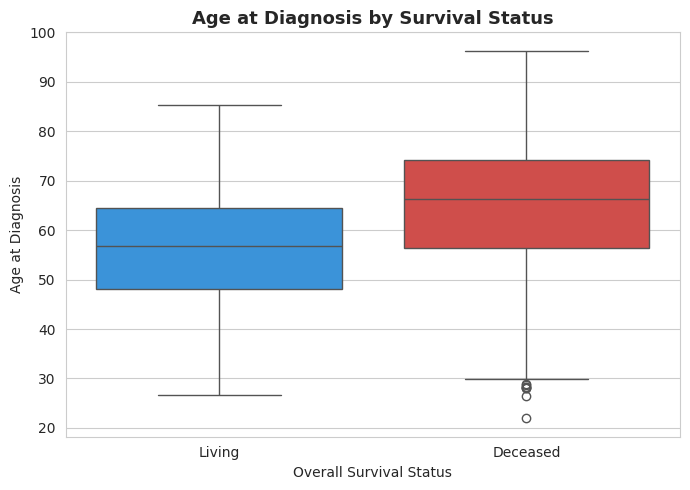

In [14]:
# ── Plot 3: Age boxplot by survival status (bivariate) ──────────────────
fig, ax = plt.subplots(figsize=(7, 5))
data_box = df_orig[['Age at Diagnosis', 'Overall Survival Status']].dropna()
sns.boxplot(x='Overall Survival Status', y='Age at Diagnosis', data=data_box,
            palette={'Living': '#2196F3', 'Deceased': '#E53935'}, ax=ax)
ax.set_title('Age at Diagnosis by Survival Status', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/03_age_boxplot.png', dpi=150); plt.show()


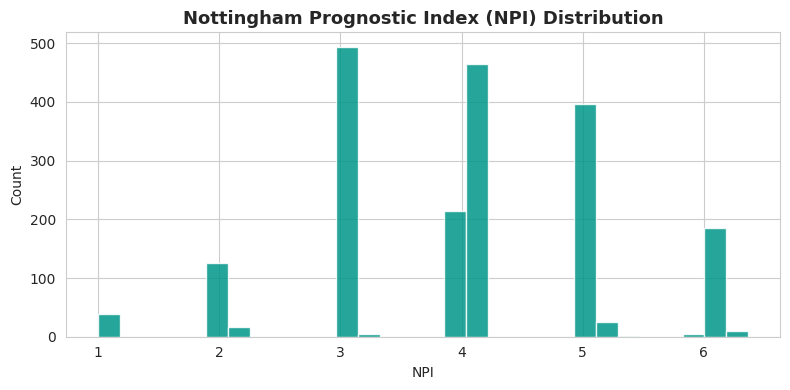

In [15]:
# ── Plot 4: Nottingham Prognostic Index histogram (univariate) ───────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_orig['Nottingham prognostic index'].dropna(), bins=30,
        color='#009688', edgecolor='white', alpha=0.85)
ax.set_title('Nottingham Prognostic Index (NPI) Distribution',
             fontsize=13, fontweight='bold')
ax.set_xlabel('NPI'); ax.set_ylabel('Count')
plt.tight_layout(); plt.savefig('plots/04_npi_histogram.png', dpi=150); plt.show()

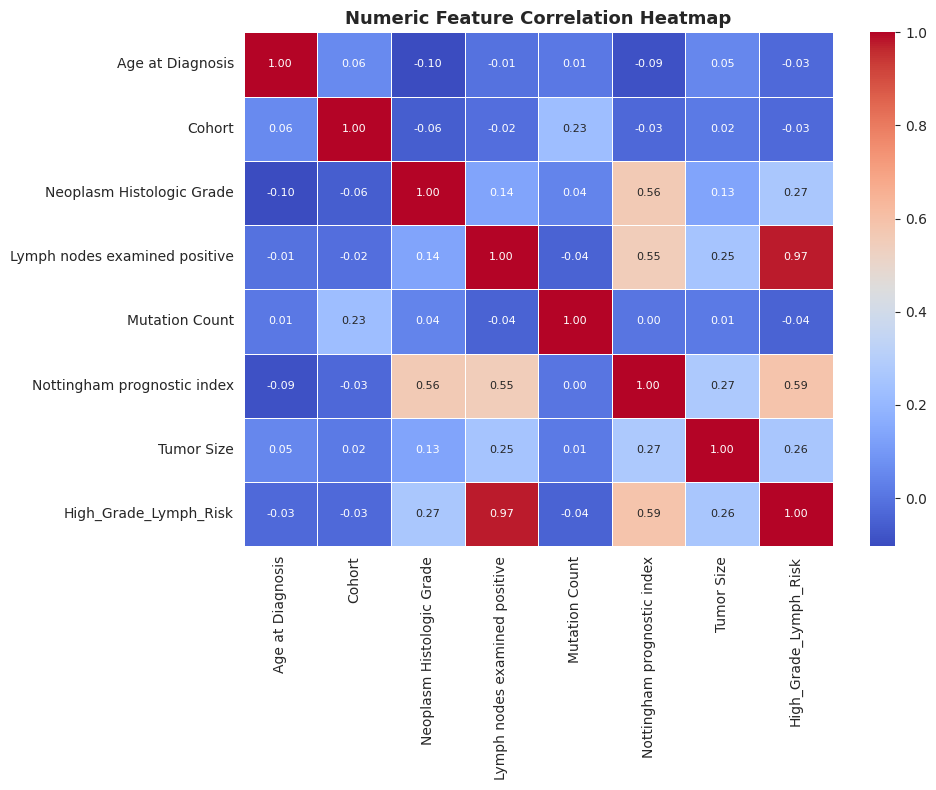

In [16]:
# ── Plot 5: Correlation heatmap (bivariate, numeric features) ────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = num_cols + ['High_Grade_Lymph_Risk']
sns.heatmap(X[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Numeric Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/05_correlation_heatmap.png', dpi=150); plt.show()


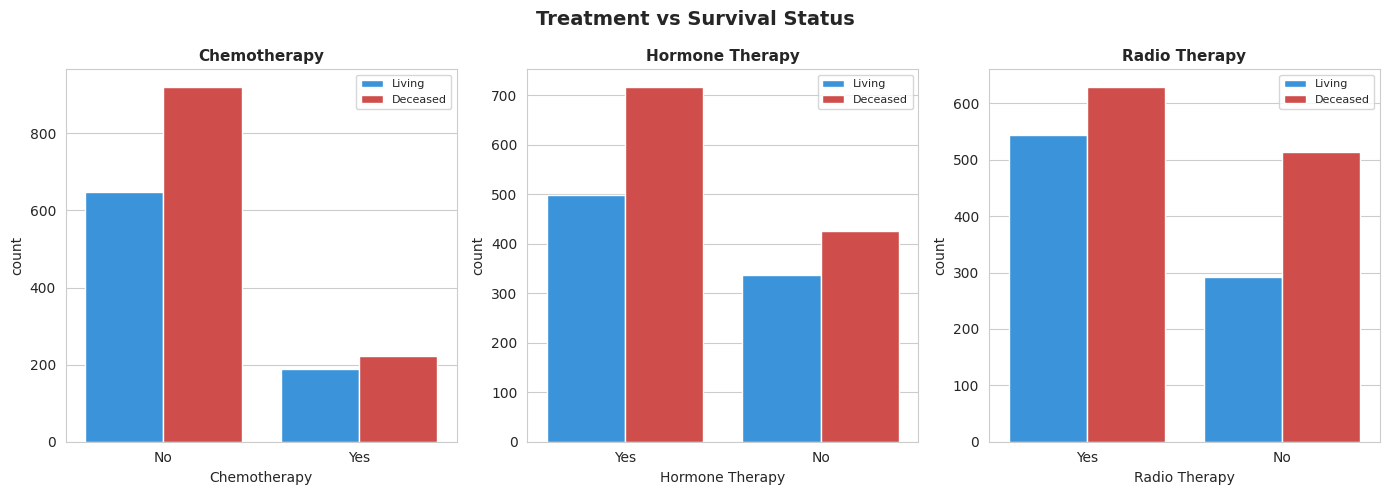

In [17]:
# ── Plot 6: Treatment countplots by survival status (bivariate) ──────────
therapies = ['Chemotherapy', 'Hormone Therapy', 'Radio Therapy']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, t in zip(axes, therapies):
    sub = df_orig[['Overall Survival Status', t]].dropna()
    sns.countplot(x=t, hue='Overall Survival Status', data=sub,
                  palette={'Living': '#2196F3', 'Deceased': '#E53935'}, ax=ax)
    ax.set_title(t, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Treatment vs Survival Status', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/06_treatment_plots.png', dpi=150); plt.show()


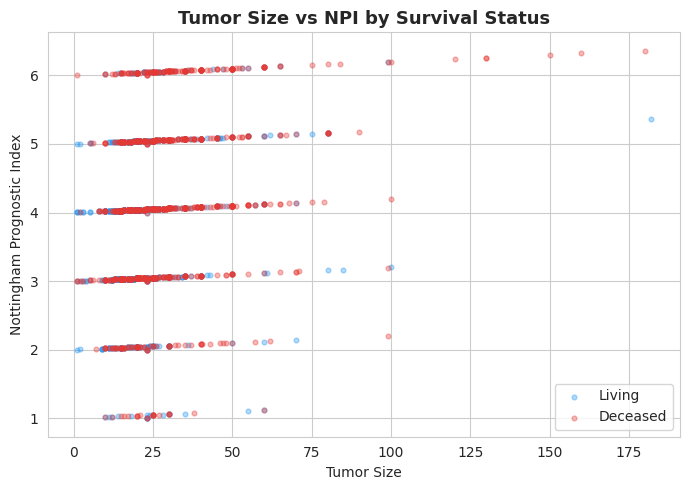

All 7 EDA plots saved.


In [19]:
# ── Plot 7: Tumor Size vs NPI scatter colored by survival (bivariate) ────
fig, ax = plt.subplots(figsize=(7, 5))
for label, grp in df.groupby('Target'):
    ax.scatter(grp['Tumor Size'], grp['Nottingham prognostic index'],
               c='#2196F3' if label == 0 else '#E53935',
               alpha=0.35, s=12,
               label='Living' if label == 0 else 'Deceased')
ax.set_xlabel('Tumor Size'); ax.set_ylabel('Nottingham Prognostic Index')
ax.set_title('Tumor Size vs NPI by Survival Status', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('plots/07_tumor_npi_scatter.png', dpi=150); plt.show()

print("All 7 EDA plots saved.")

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# ── 5.1 Scale features (required before filter method) ───────────────────
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X)

# ── 5.2 SelectKBest — ANOVA F-test (Filter Method) ───────────────────────
# Scores each feature by how strongly its mean differs across target classes.
# We keep the top 15 most statistically associated features.
selector = SelectKBest(f_classif, k=15)
selector.fit(X_scaled_all, y)

selected_features = X.columns[selector.get_support()].tolist()
print(f"Selected {len(selected_features)} features:")
for f in selected_features:
    print(f"  • {f}")

# ── 5.3 Build final feature matrix with selected features ─────────────────
X_sel = pd.DataFrame(X_scaled_all, columns=X.columns)[selected_features]
print(f"\nFinal feature matrix shape: {X_sel.shape}")

# ── 5.4 Re-fit scaler on selected features only (for deployment) ──────────
scaler_final = StandardScaler()
X_sel_scaled = scaler_final.fit_transform(X[selected_features])
X_sel = pd.DataFrame(X_sel_scaled, columns=selected_features)

Selected 15 features:
  • Age at Diagnosis
  • Type of Breast Surgery
  • Pam50 + Claudin-low subtype
  • Cohort
  • Neoplasm Histologic Grade
  • Inferred Menopausal State
  • Integrative Cluster
  • Primary Tumor Laterality
  • Lymph nodes examined positive
  • Mutation Count
  • Nottingham prognostic index
  • Radio Therapy
  • Relapse Free Status
  • Tumor Size
  • High_Grade_Lymph_Risk

Final feature matrix shape: (1981, 15)


Train size: 1584  |  Test size: 397

Logistic Regression:
  Accuracy: 0.8086
  Precision: 0.8255
  Recall: 0.8472
  F1: 0.8362
  ROC-AUC: 0.8754

Random Forest:
  Accuracy: 0.8111
  Precision: 0.8235
  Recall: 0.8559
  F1: 0.8394
  ROC-AUC: 0.8762

Gradient Boosting:
  Accuracy: 0.806
  Precision: 0.8089
  Recall: 0.869
  F1: 0.8379
  ROC-AUC: 0.8866

=== Model Comparison ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8086     0.8255  0.8472  0.8362   0.8754
Random Forest          0.8111     0.8235  0.8559  0.8394   0.8762
Gradient Boosting      0.8060     0.8089  0.8690  0.8379   0.8866


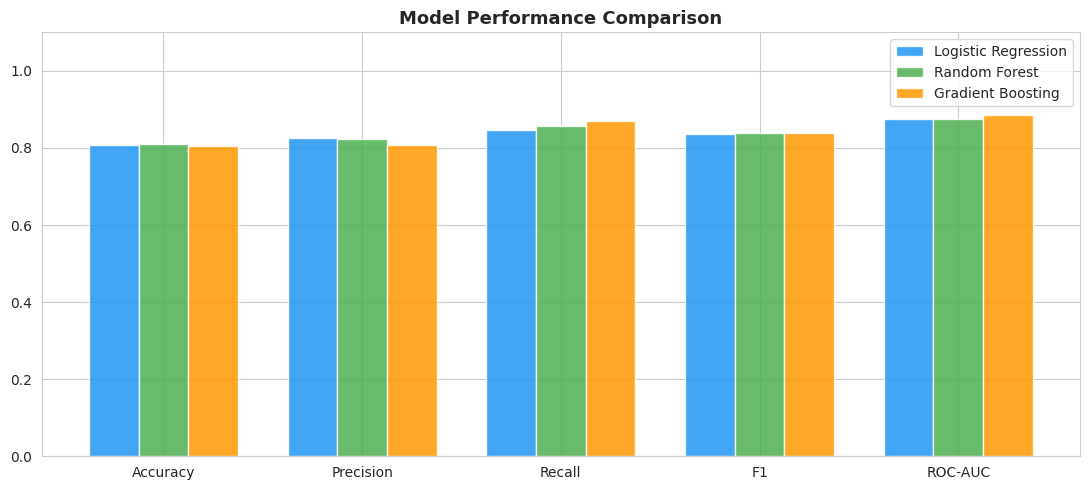

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

# ── 6.1 Train/test split (stratified to preserve class balance) ───────────
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

# ── 6.2 Define three algorithms ───────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# ── 6.3 Train each model and evaluate ────────────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
    }
    print(f"\n{name}:")
    for metric, val in results[name].items():
        print(f"  {metric}: {val}")

# ── 6.4 Print comparison table ────────────────────────────────────────────
print("\n=== Model Comparison ===")
print(pd.DataFrame(results).T.to_string())

# ── 6.5 Plot comparison bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors_m = ['#2196F3', '#4CAF50', '#FF9800']

for i, (name, res) in enumerate(results.items()):
    ax.bar(x + i * width, [res[m] for m in metrics],
           width, label=name, color=colors_m[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/08_model_comparison.png', dpi=150)
plt.show()

In [22]:
from sklearn.model_selection import GridSearchCV

# ── 7.1 Define parameter grid ─────────────────────────────────────────────
# Each combination is tested with 5-fold cross-validation.
# Scoring on F1 balances precision and recall.
param_grid = {
    'n_estimators':      [100, 200],      # number of trees
    'max_depth':         [None, 10, 20],  # max tree depth (None = unlimited)
    'min_samples_split': [2, 5],          # min samples to split a node
}

# ── 7.2 Run GridSearchCV ──────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='f1',      # optimize for F1 score
    n_jobs=-1,         # use all available CPU cores
    verbose=1,
)
grid_search.fit(X_train, y_train)

# ── 7.3 Best results ──────────────────────────────────────────────────────
print(f"Best parameters:  {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

# ── 7.4 Show all CV results sorted by rank ───────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nTop 5 configurations:")
print(
    cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(5)
    .to_string(index=False)
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 score: 0.8411

Top 5 configurations:
                                                          params  mean_test_score  std_test_score  rank_test_score
  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}         0.841127        0.028692                1
  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}         0.837917        0.025550                2
  {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}         0.834238        0.030873                3
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}         0.833788        0.030584                4
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}         0.833769        0.030958                5


=== Classification Report — Tuned Random Forest ===
              precision    recall  f1-score   support

      Living       0.82      0.73      0.77       168
    Deceased       0.82      0.88      0.85       229

    accuracy                           0.82       397
   macro avg       0.82      0.81      0.81       397
weighted avg       0.82      0.82      0.82       397

ROC-AUC: 0.8862

5-Fold CV F1 scores: [0.0087 0.7281 0.8375 0.8229 0.8224]
Mean CV F1: 0.6439 ± 0.3200


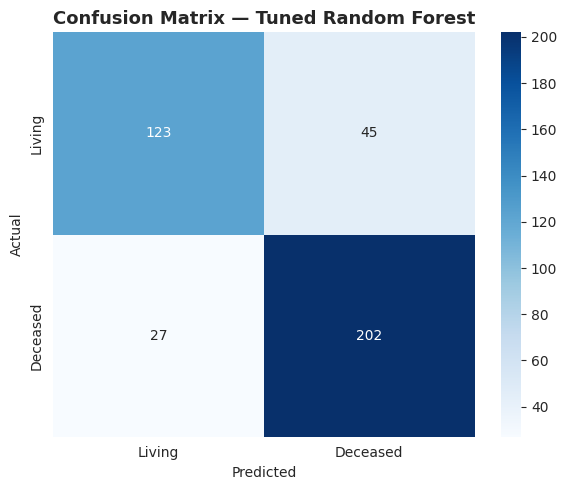

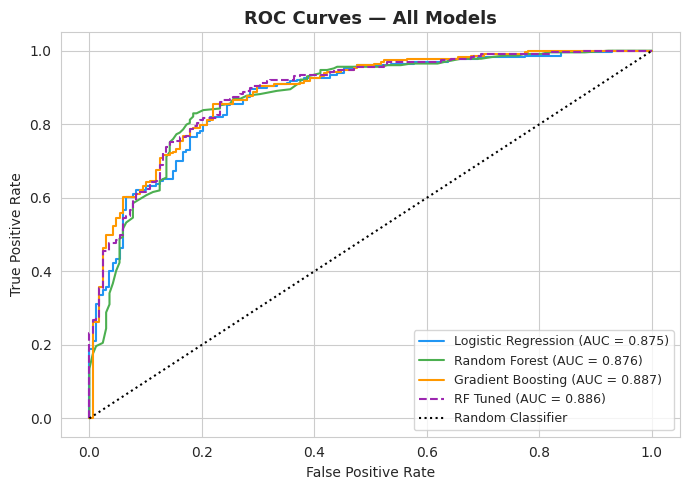

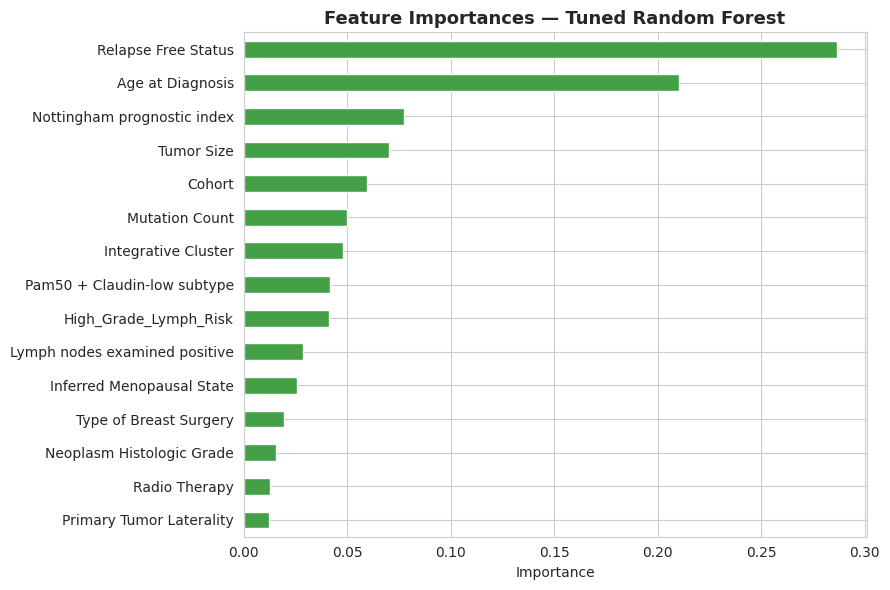

In [23]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score)
from sklearn.model_selection import cross_val_score

# ── 8.1 Predictions from tuned model ─────────────────────────────────────
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

# ── 8.2 Full classification report ───────────────────────────────────────
print("=== Classification Report — Tuned Random Forest ===")
print(classification_report(y_test, y_pred_best,
                             target_names=['Living', 'Deceased']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

# ── 8.3 Cross-validation score on full training set ───────────────────────
# Validation: tests that performance generalizes, not just memorized training data
cv_scores = cross_val_score(best_rf, X_sel, y, cv=5, scoring='f1')
print(f"\n5-Fold CV F1 scores: {cv_scores.round(4)}")
print(f"Mean CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── 8.4 Plot: Confusion Matrix ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Living', 'Deceased'],
            yticklabels=['Living', 'Deceased'])
ax.set_title('Confusion Matrix — Tuned Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.savefig('plots/09_confusion_matrix.png', dpi=150); plt.show()

# ── 8.5 Plot: ROC Curves for all models ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
roc_colors = ['#2196F3', '#4CAF50', '#FF9800']

for (name, model), color in zip(models.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color)

# Add tuned RF
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_best)
auc_b = roc_auc_score(y_test, y_prob_best)
ax.plot(fpr_b, tpr_b, '--', color='#9C27B0',
        label=f'RF Tuned (AUC = {auc_b:.3f})')
ax.plot([0, 1], [0, 1], 'k:', label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('plots/10_roc_curves.png', dpi=150); plt.show()

# ── 8.6 Plot: Feature Importances ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
importances = pd.Series(
    best_rf.feature_importances_, index=selected_features
).sort_values()
importances.plot(kind='barh', ax=ax, color='#43A047', edgecolor='white')
ax.set_title('Feature Importances — Tuned Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.savefig('plots/11_feature_importances.png', dpi=150); plt.show()

In [24]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# ── Save all artifacts needed for deployment ──────────────────────────────
joblib.dump(best_rf,          'models/best_model_rf.pkl')
joblib.dump(scaler_final,     'models/scaler.pkl')
joblib.dump(selected_features,'models/selected_features.pkl')
joblib.dump(num_imp,          'models/num_imputer.pkl')
joblib.dump(cat_imp,          'models/cat_imputer.pkl')

print("Saved:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f"  models/{f}  ({size:,} bytes)")

# ── Verify: reload and re-predict to confirm saved model works ────────────
model_loaded    = joblib.load('models/best_model_rf.pkl')
scaler_loaded   = joblib.load('models/scaler.pkl')
features_loaded = joblib.load('models/selected_features.pkl')

sample = X_test.iloc[:5]
preds_original = best_rf.predict(sample)
preds_loaded   = model_loaded.predict(sample)

print("\nOriginal predictions:", preds_original)
print("Loaded predictions:  ", preds_loaded)
assert (preds_original == preds_loaded).all(), "Mismatch! Something went wrong."
print("Model reload verified successfully.")

Saved:
  models/scaler.pkl  (1,551 bytes)
  models/best_model_rf.pkl  (4,902,521 bytes)
  models/selected_features.pkl  (358 bytes)
  models/num_imputer.pkl  (943 bytes)
  models/cat_imputer.pkl  (1,335 bytes)

Original predictions: [1 1 1 0 1]
Loaded predictions:   [1 1 1 0 1]
Model reload verified successfully.
